# Dataset
[Binary Classification Moons](./Resources/binary_classification_moons.csv)

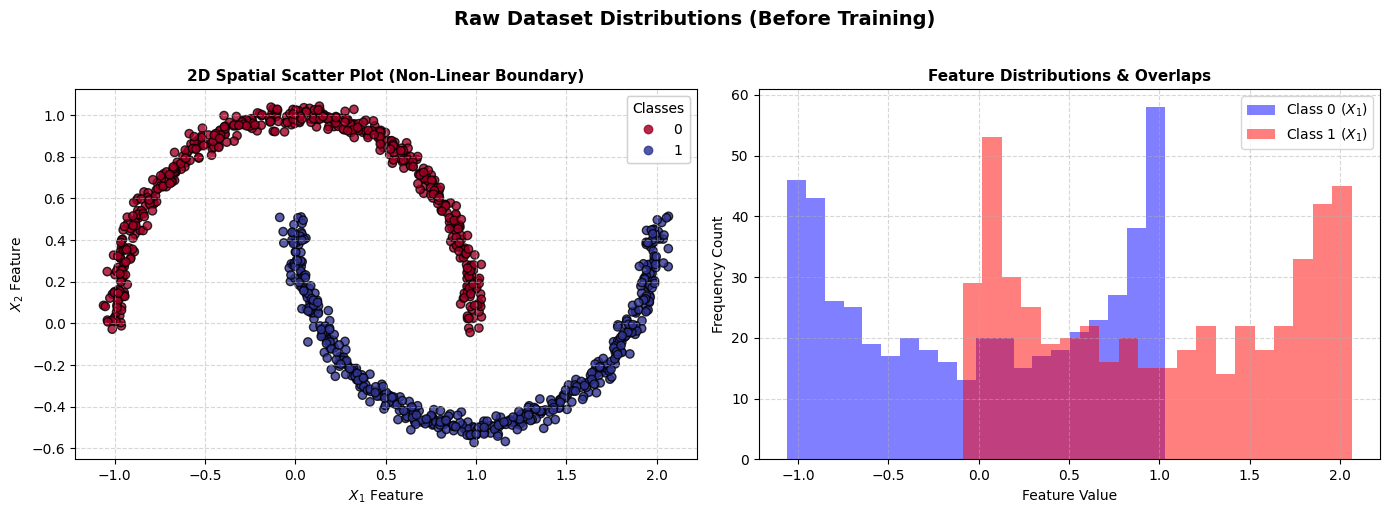

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Load dataset
df = pd.read_csv('./Resources/binary_classification_moons.csv')

# Initialize a 1x2 subplot figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter Plot - Visualizing the "Moons" structure
scatter = axes[0].scatter(
    x=df['X1'], 
    y=df['X2'], 
    c=df['label'], 
    cmap=plt.cm.RdYlBu, 
    edgecolor='k', 
    alpha=0.8
)
axes[0].set_title("2D Spatial Scatter Plot (Non-Linear Boundary)", fontsize=11, fontweight='semibold')
axes[0].set_xlabel("$X_1$ Feature")
axes[0].set_ylabel("$X_2$ Feature")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Add a legend for the classes
legend = axes[0].legend(*scatter.legend_elements(), title="Classes", loc="upper right")
axes[0].add_artist(legend)

# 2. Histogram/Density Plot - Visualizing feature spreads
axes[1].hist(df[df['label'] == 0]['X1'], bins=20, alpha=0.5, label='Class 0 ($X_1$)', color='blue')
axes[1].hist(df[df['label'] == 1]['X1'], bins=20, alpha=0.5, label='Class 1 ($X_1$)', color='red')
axes[1].set_title("Feature Distributions & Overlaps", fontsize=11, fontweight='semibold')
axes[1].set_xlabel("Feature Value")
axes[1].set_ylabel("Frequency Count")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle='--', alpha=0.5)

# Layout adjustments matching your template
plt.suptitle("Raw Dataset Distributions (Before Training)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Data Loading and Preparation**

In [20]:
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup device and load data safely (.copy() prevents the UserWarning)
device = "cuda" if torch.cuda.is_available() else "cpu"
df = pd.read_csv('./Resources/binary_classification_moons.csv')
X = torch.from_numpy(df[['X1', 'X2']].values.copy()).type(torch.float)
y = torch.from_numpy(df['label'].values.copy()).type(torch.float).unsqueeze(1)

# 2. Split into Train/Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# 3. Define the Linear Regression NN Architecture
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=2, out_features=1, bias=True)

    def forward(self, x):
        return self.linear(x)

# 4. Instantiate model, loss function, and optimizer
model_linear = LinearRegressionNN().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_linear.parameters(), lr=0.1)

## **Training loop and model evaluation**

Starting Training for LinearRegressionNN...
--------------------------------------------------
Epoch:   0 | Train Loss: 0.69711, Acc: 47.00% | Test Loss: 0.70987, Test Acc: 45.50%
Epoch:  20 | Train Loss: 0.58079, Acc: 62.50% | Test Loss: 0.60282, Test Acc: 57.00%
Epoch:  40 | Train Loss: 0.51060, Acc: 70.75% | Test Loss: 0.53662, Test Acc: 64.00%
Epoch:  60 | Train Loss: 0.46484, Acc: 74.88% | Test Loss: 0.49240, Test Acc: 68.00%
Epoch:  80 | Train Loss: 0.43289, Acc: 77.25% | Test Loss: 0.46082, Test Acc: 71.00%
Epoch: 100 | Train Loss: 0.40929, Acc: 78.88% | Test Loss: 0.43700, Test Acc: 73.50%


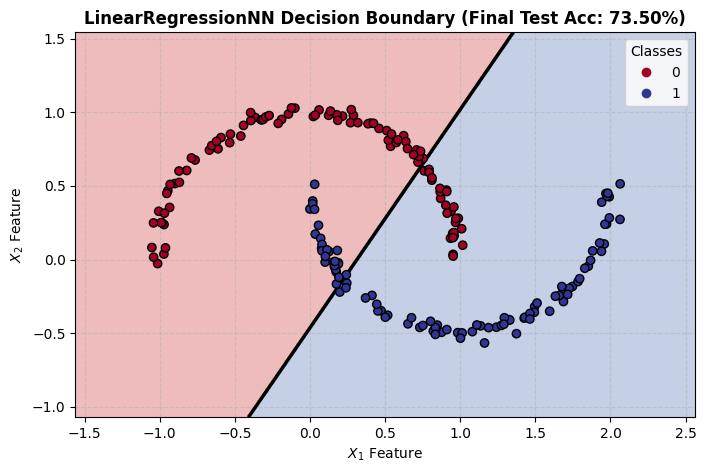

In [21]:
torch.manual_seed(42)
epochs = 100

print("Starting Training for LinearRegressionNN...\n" + "-"*50)
for epoch in range(epochs + 1):
    model_linear.train()
    y_logits = model_linear(X_train)
    loss = loss_fn(y_logits, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        model_linear.eval()
        with torch.inference_mode():
            test_logits = model_linear(X_test)
            test_loss = loss_fn(test_logits, y_test)
            train_preds = torch.round(torch.sigmoid(y_logits))
            test_preds = torch.round(torch.sigmoid(test_logits))
            train_acc = (train_preds == y_train).sum().item() / len(y_train) * 100
            test_acc = (test_preds == y_test).sum().item() / len(y_test) * 100
            
        print(f"Epoch: {epoch:3d} | Train Loss: {loss.item():.5f}, Acc: {train_acc:.2f}% | Test Loss: {test_loss.item():.5f}, Test Acc: {test_acc:.2f}%")

# --- PLOTTING CODE ---
model_linear.eval()
with torch.inference_mode():
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).type(torch.float).to(device)
    
    # Get continuous prediction values (logits) to find the exact 0.0 threshold
    grid_logits = model_linear(grid).reshape(xx.shape).cpu().numpy()
    grid_preds = torch.round(torch.sigmoid(torch.from_numpy(grid_logits))).numpy()

# Generate Plot
plt.figure(figsize=(8, 5))
# Shaded background
plt.contourf(xx, yy, grid_preds, cmap=plt.cm.RdYlBu, alpha=0.3)

# NEW: Explicitly drawing the decision boundary line at threshold 0
plt.contour(xx, yy, grid_logits, levels=[0], colors='black', linewidths=2.5, linestyles='solid')

# Scatter data points
scatter = plt.scatter(X_test[:, 0].cpu(), X_test[:, 1].cpu(), c=y_test.cpu().squeeze(), cmap=plt.cm.RdYlBu, edgecolors='k', zorder=3)
plt.title(f"LinearRegressionNN Decision Boundary (Final Test Acc: {test_acc:.2f}%)", fontsize=12, fontweight='bold')
plt.xlabel("$X_1$ Feature")
plt.ylabel("$X_2$ Feature")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Understanding the graph
The decision boundary is explicitly outlined in black, we can observe that the `LinearRegressionNN` model splits the feature space using a **strictly straight line**. Because the dataset consists of two interlocking, non-linear crescent moons, a straight line is mathematically incapable of separating them. The blue points curling into the upper-left region are forced into "red territory," causing the model's accuracy to diminish at around **73.50%** (underfitting).




## MLP (Multi-Layer Perceptron)
- theory of mlp here
- fig pani if possible


In [22]:
# 1. Define ModelV0 (mlp)
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        # A chain of linear layers with NO activation function in between
        return self.layer_2(self.layer_1(x))

# 2. Instantiate model, loss, and optimizer
model_v0 = ModelV0().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_v0.parameters(), lr=0.1)

Starting Training for ModelV0...
--------------------------------------------------
Epoch:   0 | Train Loss: 0.69395, Acc: 50.00% | Test Loss: 0.68147, Test Acc: 58.50%
Epoch:  20 | Train Loss: 0.48652, Acc: 81.12% | Test Loss: 0.49746, Test Acc: 79.00%
Epoch:  40 | Train Loss: 0.38463, Acc: 82.25% | Test Loss: 0.40451, Test Acc: 81.00%
Epoch:  60 | Train Loss: 0.33707, Acc: 83.12% | Test Loss: 0.35814, Test Acc: 81.50%
Epoch:  80 | Train Loss: 0.31201, Acc: 84.00% | Test Loss: 0.33141, Test Acc: 82.00%
Epoch: 100 | Train Loss: 0.29602, Acc: 85.00% | Test Loss: 0.31303, Test Acc: 84.00%


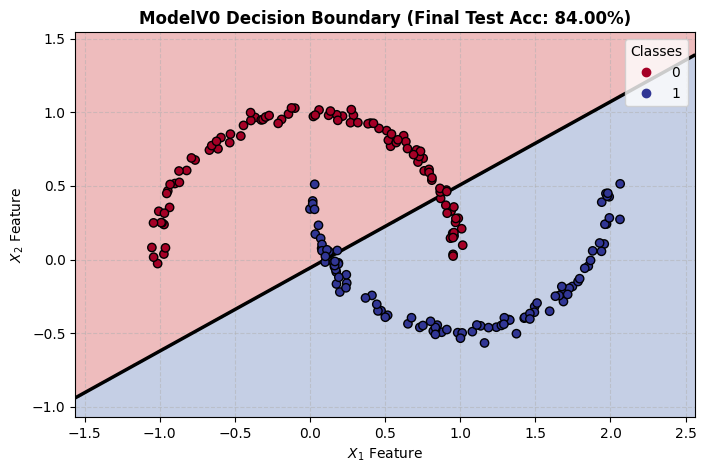

In [23]:
torch.manual_seed(42)
epochs = 100

print("Starting Training for ModelV0...\n" + "-"*50)
for epoch in range(epochs + 1):
    model_v0.train()
    y_logits = model_v0(X_train)
    loss = loss_fn(y_logits, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        model_v0.eval()
        with torch.inference_mode():
            test_logits = model_v0(X_test)
            test_loss = loss_fn(test_logits, y_test)
            train_preds = torch.round(torch.sigmoid(y_logits))
            test_preds = torch.round(torch.sigmoid(test_logits))
            train_acc = (train_preds == y_train).sum().item() / len(y_train) * 100
            test_acc = (test_preds == y_test).sum().item() / len(y_test) * 100
            
        print(f"Epoch: {epoch:3d} | Train Loss: {loss.item():.5f}, Acc: {train_acc:.2f}% | Test Loss: {test_loss.item():.5f}, Test Acc: {test_acc:.2f}%")

# --- PLOTTING CODE ---
model_v0.eval()
with torch.inference_mode():
    grid_logits = model_v0(grid).reshape(xx.shape).cpu().numpy()
    grid_preds = torch.round(torch.sigmoid(torch.from_numpy(grid_logits))).numpy()

# Generate Plot
plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, grid_preds, cmap=plt.cm.RdYlBu, alpha=0.3)
# Bold visible black line showing the boundary split
plt.contour(xx, yy, grid_logits, levels=[0], colors='black', linewidths=2.5)
scatter = plt.scatter(X_test[:, 0].cpu(), X_test[:, 1].cpu(), c=y_test.cpu().squeeze(), cmap=plt.cm.RdYlBu, edgecolors='k', zorder=3)

plt.title(f"ModelV0 Decision Boundary (Final Test Acc: {test_acc:.2f}%)", fontsize=12, fontweight='bold')
plt.xlabel("$X_1$ Feature")
plt.ylabel("$X_2$ Feature")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

despite two layers the model can't accurately work yet

## How to Increase Model Accuracy?
* increasing number of layers
* altering hidden units